In [1]:
!python --version

Python 3.12.3


# 下載套檢

In [12]:
!pip install scikit-survival

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 18.4 MB/s eta 0:00:00 0:00:01


In [2]:
!pip install xgbse

In [3]:
!pip install openpyxl

In [4]:
!pip uninstall -y scikit-survival
!pip install scikit-survival==0.22.1

Found existing installation: scikit-survival 0.24.1
Uninstalling scikit-survival-0.24.1:
  Successfully uninstalled scikit-survival-0.24.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 12.4 MB/s eta 0:00:00:--:--
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [108 lines of output]
      performance hint: sksurv/kernels/_clinical_kernel.pyx:20:0: Exception check on '_get_min_and_max' will always require the GIL to be acquired.
      Possible solutions:
          1. Declare '_get_min_and_max' as 'noexcept' if you control the definition and you're sure you don't want the function to raise exceptions.
          2. Use an 'int' return type on '_get_min_and_max' to allow an error code to be returned.
      performance hint: sksurv/kernels/_clinical_kernel.pyx:75:28: Exception check after calling '_get_min_and_ma

In [5]:
!pip install torchtuples pycox


In [6]:
!pip install interpret


In [7]:
!pip install lifelines


In [7]:
!pip install shap

# 資料分割、標準化 (存成 doctor_dataset_split.xlsx)








In [2]:
import pandas as pd

df_Dr_selected = pd.read_excel(r"/home/claire901114/碩論/doctor_selected_feature_data.xlsx")
##c## df_Dr_selected = pd.read_excel(r"/content/doctor_selected_feature_data.xlsx")

df_Dr_selected.head()  # 顯示前幾列確認資料成功載入

,ID,Age,ECOG,SMI_1,Stage_2,Cell_2,Grade,Resec_status,Ascites_1,BMI_1,Alb_11,NLR_1,PLR_1,OS,OS_year,PFS,PFS_year
0,8,46,0,44.450299,1,0,3,0,0,21.905228,43.0,2.333333,123.638344,0,7.178082,0,7.178082
1,9,67,0,52.673128,1,0,3,2,1,25.437481,45.0,1.933333,234.166667,1,10.339726,1,2.136986
2,10,48,0,48.800000,1,1,2,0,0,24.711111,40.0,5.133333,152.542373,0,3.572603,0,3.572603
3,11,45,0,47.417660,1,0,3,1,1,25.118544,41.0,6.153846,314.580941,0,11.063014,0,11.063014
4,12,58,0,40.637684,1,0,3,0,0,22.886205,41.0,6.500000,400.684932,0,11.000000,0,11.000000


In [ ]:
print("資料形狀：", df_Dr_selected.shape)
print("📊 df_Dr_selected 樣本數（rows）:", df_Dr_selected.shape[0])
print("📊 df_Dr_selected 特徵數（columns）:", df_Dr_selected.shape[1])

資料形狀： (627, 17)
📊 df_Dr_selected 樣本數（rows）: 627
📊 df_Dr_selected 特徵數（columns）: 17


In [ ]:
# 找出包含缺失值的樣本（列）
missing_samples = df_Dr_selected[df_Dr_selected.isnull().any(axis=1)]

# 顯示前幾筆樣本（可改為 .to_csv(...) 輸出）
print(f"🔍 共 {len(missing_samples)} 筆樣本含有缺失值：")
display(missing_samples.head())

🔍 共 0 筆樣本含有缺失值：


,ID,Age,ECOG,SMI_1,Stage_2,Cell_2,Grade,Resec_status,Ascites_1,BMI_1,Alb_11,NLR_1,PLR_1,OS,OS_year,PFS,PFS_year


In [ ]:
# 拆分資料(80train 20test)
from sklearn.model_selection import train_test_split

X = df_Dr_selected.drop(columns=['ID','OS', 'OS_year','PFS', 'PFS_year'])
# 合併時間與事件變數
y = df_Dr_selected[['OS_year', 'OS']]  # ← 一次包含兩個 y

# 資料切分（按事件 stratify）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y['OS'], random_state=42)

# 切出時間與事件
y_OS_time_train = y_train['OS_year']
y_OS_event_train = y_train['OS']

y_OS_time_test = y_test['OS_year']
y_OS_event_test = y_test['OS']

In [ ]:
# 訓練集事件統計
train_OS_event_counts = y_OS_event_train.value_counts()
print("📊 訓練集 OS 事件分布：")
print(train_OS_event_counts)
print(f"事件比例: {train_OS_event_counts[1] / train_OS_event_counts.sum():.2%} 發生, {train_OS_event_counts[0] / train_OS_event_counts.sum():.2%} 未發生\n")

# 測試集事件統計
test_OS_event_counts = y_OS_event_test.value_counts()
print("📊 測試集 OS 事件分布：")
print(test_OS_event_counts)
print(f"事件比例: {test_OS_event_counts[1] / test_OS_event_counts.sum():.2%} 發生, {test_OS_event_counts[0] / test_OS_event_counts.sum():.2%} 未發生")

📊 訓練集 OS 事件分布：
OS
0    323
1    178
Name: count, dtype: int64
事件比例: 35.53% 發生, 64.47% 未發生

📊 測試集 OS 事件分布：
OS
0    81
1    45
Name: count, dtype: int64
事件比例: 35.71% 發生, 64.29% 未發生


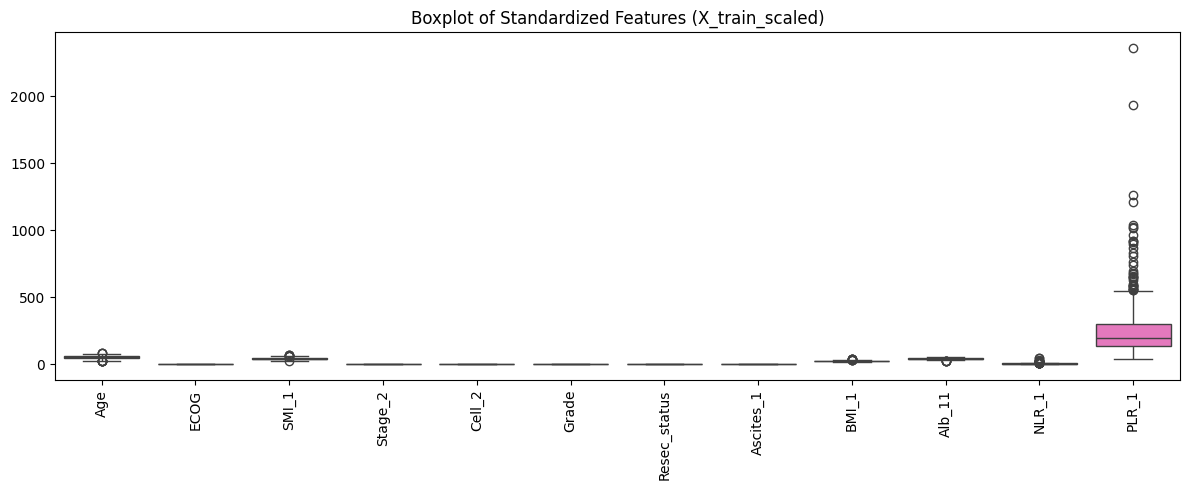

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# 使用 seaborn 畫出標準化後訓練特徵的箱型圖（每個特徵一個箱型）
sns.boxplot(data=pd.DataFrame(X_train, columns=X_train.columns))
plt.xticks(rotation=90)
plt.title("Boxplot of Standardized Features (X_train_scaled)")
plt.tight_layout()
plt.show()

In [ ]:
# 標準化特徵
from sklearn.preprocessing import StandardScaler

# 假設你知道哪些是二分類特徵，可以排除它們
binary_features = ['ECOG', 'Stage_2', 'Cell_2', 'Grade', 'Resec_status', 'Ascites_1']  # 根據實際欄位調整
continuous_features = [col for col in X_train.columns if col not in binary_features]

scaler = StandardScaler()
# 複製資料
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# 只標準化連續特徵
scaler = StandardScaler()
X_train_scaled[continuous_features] = scaler.fit_transform(X_train[continuous_features])
X_test_scaled[continuous_features] = scaler.transform(X_test[continuous_features])


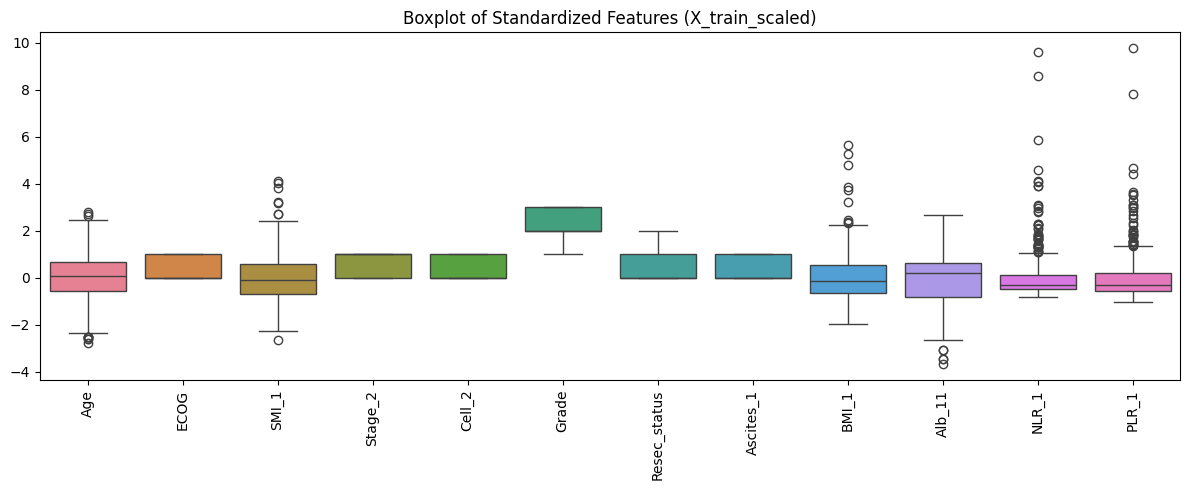

In [ ]:
plt.figure(figsize=(12, 5))

# 使用 seaborn 畫出標準化後訓練特徵的箱型圖（每個特徵一個箱型）
sns.boxplot(data=pd.DataFrame(X_train_scaled, columns=X_train.columns))
plt.xticks(rotation=90)
plt.title("Boxplot of Standardized Features (X_train_scaled)")
plt.tight_layout()
plt.show()

In [ ]:
# ----------- 合併資料集與 OS 標籤（只包含 OS, OS_year）------------
X_train_ori = X_train.copy()
X_train_ori[['OS', 'OS_year']] = y_train[['OS', 'OS_year']].values

X_train_std = X_train_scaled.copy()
X_train_std[['OS', 'OS_year']] = y_train[['OS', 'OS_year']].values

X_test_ori = X_test.copy()
X_test_ori[['OS', 'OS_year']] = y_test[['OS', 'OS_year']].values

X_test_std = X_test_scaled.copy()
X_test_std[['OS', 'OS_year']] = y_test[['OS', 'OS_year']].values

# ----------- 儲存成 Excel 多工作表檔案 ------------
with pd.ExcelWriter("doc_OS_train_test_split.xlsx", engine="openpyxl") as writer:
    X_train_ori.to_excel(writer, sheet_name="Train_Original", index=False)
    X_train_std.to_excel(writer, sheet_name="Train_Scaled", index=False)
    X_test_ori.to_excel(writer, sheet_name="Test_Original", index=False)
    X_test_std.to_excel(writer, sheet_name="Test_Scaled", index=False)


In [ ]:
# 訓練集事件統計
train_OS_event_counts = y_OS_event_train.value_counts()
print("📊 訓練集 OS 事件分布：")
print(train_OS_event_counts)
print(f"事件比例: {train_OS_event_counts[1] / train_OS_event_counts.sum():.2%} 發生, {train_OS_event_counts[0] / train_OS_event_counts.sum():.2%} 未發生\n")

# 測試集事件統計
test_OS_event_counts = y_OS_event_test.value_counts()
print("📊 測試集 OS 事件分布：")
print(test_OS_event_counts)
print(f"事件比例: {test_OS_event_counts[1] / test_OS_event_counts.sum():.2%} 發生, {test_OS_event_counts[0] / test_OS_event_counts.sum():.2%} 未發生")

📊 訓練集 OS 事件分布：
OS
0    323
1    178
Name: count, dtype: int64
事件比例: 35.53% 發生, 64.47% 未發生

📊 測試集 OS 事件分布：
OS
0    81
1    45
Name: count, dtype: int64
事件比例: 35.71% 發生, 64.29% 未發生


# 直接讀取切分好的資料集 doctor_dataset_split.xlsx

In [1]:
import pandas as pd
# 讀取 Excel 各分頁
file_path = "doc_OS_train_test_split.xlsx"

df_train_ori = pd.read_excel(file_path, sheet_name="Train_Original")
df_train_std = pd.read_excel(file_path, sheet_name="Train_Scaled")
df_test_ori = pd.read_excel(file_path, sheet_name="Test_Original")
df_test_std = pd.read_excel(file_path, sheet_name="Test_Scaled")

# 還原特徵與目標變數（Training Set）
X_train = df_train_ori.drop(columns=["OS", "OS_year"])
y_OS_event_train = df_train_ori["OS"]
y_OS_time_train = df_train_ori["OS_year"]

# 還原特徵與目標變數（Training Set Scaled）
X_train_scaled = df_train_std.drop(columns=["OS", "OS_year"])

# 還原特徵與目標變數（Testing Set）
X_test = df_test_ori.drop(columns=["OS", "OS_year"])
y_OS_event_test = df_test_ori["OS"]
y_OS_time_test = df_test_ori["OS_year"]

# 還原特徵與目標變數（Testing Set Scaled）
X_test_scaled = df_test_std.drop(columns=["OS", "OS_year"])


In [2]:
# 訓練集事件統計
train_OS_event_counts = y_OS_event_train.value_counts()
print("📊 訓練集 OS 事件分布：")
print(train_OS_event_counts)
print(f"事件比例: {train_OS_event_counts[1] / train_OS_event_counts.sum():.2%} 發生, {train_OS_event_counts[0] / train_OS_event_counts.sum():.2%} 未發生\n")

# 測試集事件統計
test_OS_event_counts = y_OS_event_test.value_counts()
print("📊 測試集 OS 事件分布：")
print(test_OS_event_counts)
print(f"事件比例: {test_OS_event_counts[1] / test_OS_event_counts.sum():.2%} 發生, {test_OS_event_counts[0] / test_OS_event_counts.sum():.2%} 未發生")

📊 訓練集 OS 事件分布：
OS
0    323
1    178
Name: count, dtype: int64
事件比例: 35.53% 發生, 64.47% 未發生

📊 測試集 OS 事件分布：
OS
0    81
1    45
Name: count, dtype: int64
事件比例: 35.71% 發生, 64.29% 未發生


# 建立 cox RSF survival_SVM

In [3]:
############ 建立OS模型 ####################

In [4]:
from sksurv.util import Surv
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored, cumulative_dynamic_auc, brier_score

import numpy as np

# 建立生存標籤格式
y_train_struct = Surv.from_arrays(event=y_OS_event_train.astype(bool), time=y_OS_time_train)
y_test_struct = Surv.from_arrays(event=y_OS_event_test.astype(bool), time=y_OS_time_test)

In [5]:
print(y_train_struct[:5])

[( True, 3.51780822) (False, 3.6       ) ( True, 4.69589041)
 (False, 3.83013699) (False, 4.34246575)]


In [6]:
############ cox ####################

cox = CoxPHSurvivalAnalysis()
# 若您已標準化資料為 X_train_scaled 和 X_test_scaled
cox.fit(X_train_scaled, y_train_struct)
cindex_cox = cox.score(X_test_scaled, y_test_struct)
print(f"📈 CoxPH C-index (standardized): {cindex_cox:.4f}")

📈 CoxPH C-index (standardized): 0.8490


In [7]:
############ RSF boostrap ####################

from sklearn.utils import resample
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === 參數設定 ===
rsf_num_bs = 500
rsf_n_samples = len(X_train_scaled)

# === 儲存結果 ===
rsf_bootstrap_metrics = []
rsf_bootstrap_models = []

# === Bootstrap Validation ===
for rsf_round in range(rsf_num_bs):
    rsf_bs_index = np.random.choice(rsf_n_samples, size=int(rsf_n_samples * 0.9), replace=True)
    rsf_val_index = np.setdiff1d(np.arange(rsf_n_samples), np.unique(rsf_bs_index))

    if len(rsf_val_index) < int(0.1 * rsf_n_samples):
        continue

    rsf_X_train_bs = X_train_scaled.iloc[rsf_bs_index]
    rsf_y_train_bs = y_train_struct[rsf_bs_index]

    rsf_X_val_bs = X_train_scaled.iloc[rsf_val_index]
    rsf_y_val_bs = y_train_struct[rsf_val_index]

    rsf_model = RandomSurvivalForest(n_estimators=100, random_state=rsf_round, n_jobs=-1)
    rsf_model.fit(rsf_X_train_bs, rsf_y_train_bs)

    rsf_pred_val = rsf_model.predict(rsf_X_val_bs)
    rsf_c_index = concordance_index_censored(
        rsf_y_val_bs["event"], rsf_y_val_bs["time"], rsf_pred_val
    )[0]

    rsf_bootstrap_metrics.append({
        "bootstrap_round": rsf_round,
        "c_index": rsf_c_index
    })
    rsf_bootstrap_models.append(rsf_model)


In [8]:
# === 結果彙整 ===
rsf_df_metrics = pd.DataFrame(rsf_bootstrap_metrics)
print("✅ RSF Bootstrap Validation 完成")
print("平均 C-index:", rsf_df_metrics["c_index"].mean())
print("標準差:", rsf_df_metrics["c_index"].std())


✅ RSF Bootstrap Validation 完成
平均 C-index: 0.8196989854841142
標準差: 0.017542153575364768


🔍 RSF Bootstrap C-index 平均: 0.8196989854841142
📉 標準差 (std): 0.017542153575364768
📏 最大 - 最小差距: 0.098016682812742


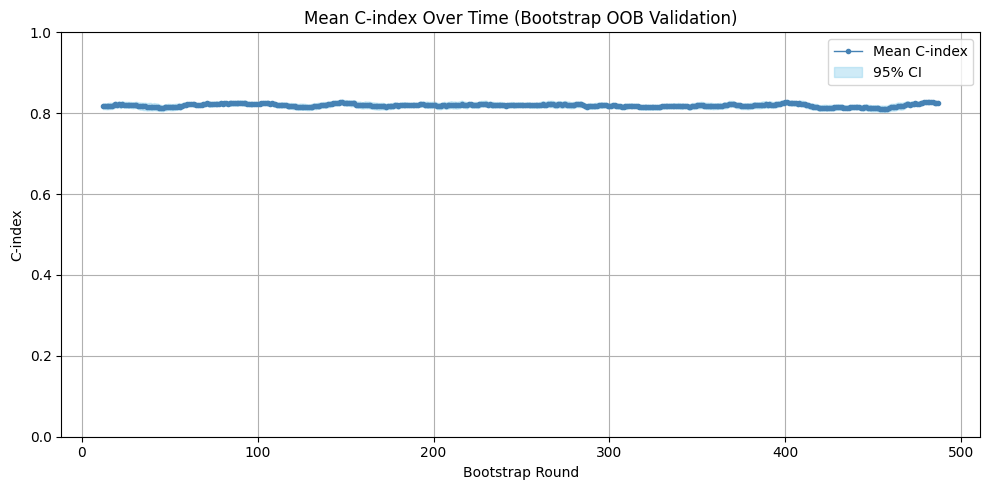

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 假設你已有 rsf_df_metrics["c_index"]
window_size = 25  # 可調整平滑程度

# 平滑與 CI 計算
rolling_mean = rsf_df_metrics["c_index"].rolling(window=window_size, center=True).mean()
rolling_std = rsf_df_metrics["c_index"].rolling(window=window_size, center=True).std()
ci_upper = rolling_mean + 1.96 * (rolling_std / np.sqrt(window_size))
ci_lower = rolling_mean - 1.96 * (rolling_std / np.sqrt(window_size))


# 計算統計值
print("🔍 RSF Bootstrap C-index 平均:", rsf_df_metrics["c_index"].mean())
print("📉 標準差 (std):", rsf_df_metrics["c_index"].std())
print("📏 最大 - 最小差距:", rsf_df_metrics["c_index"].max() - rsf_df_metrics["c_index"].min())

# 第二張：平滑平均 + 信賴區間圖
plt.figure(figsize=(10, 5))
plt.plot(rolling_mean, label="Mean C-index", color="steelblue", marker='o', markersize=3, linewidth=1)
plt.fill_between(range(len(rolling_mean)), ci_lower, ci_upper, color="skyblue", alpha=0.4, label="95% CI")
plt.title("Mean C-index Over Time (Bootstrap OOB Validation)")
plt.xlabel("Bootstrap Round")
plt.ylabel("C-index")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



參考標準（經驗值）：

標準差 < 0.02 → 高穩定性

標準差在 0.02 ~ 0.05 → 可接受

標準差 > 0.05 → 可能過度擬合或資料異質性高

In [10]:
#------ 最終結果: 方法1 -------
# 選出 bootstrap 驗證集中 C-index 最佳的模型
rsf_best_idx = rsf_df_metrics["c_index"].idxmax()
rsf_best_model = rsf_bootstrap_models[rsf_best_idx]

# 在測試集上進行預測
rsf_pred_test_best_model = rsf_best_model.predict(X_test_scaled)

# 計算 C-index（測試集）
rsf_test_cindex_best_model = concordance_index_censored(
    y_test_struct["event"], y_test_struct["time"], rsf_pred_test_best_model
)[0]

print("🌟 使用 bootstrap 最佳模型在測試集上的 C-index:", rsf_test_cindex_best_model)


🌟 使用 bootstrap 最佳模型在測試集上的 C-index: 0.8407871198568873


In [11]:
#------ 最終結果: 方法2 -------
# === 使用完整訓練集重訓模型 ===
rsf_final_model = RandomSurvivalForest(n_estimators=100, random_state=42, n_jobs=-1)
rsf_final_model.fit(X_train_scaled, y_train_struct)

# === 測試集預測與 C-index 評估 ===
rsf_pred_test = rsf_final_model.predict(X_test_scaled)
rsf_test_cindex = concordance_index_censored(
    y_test_struct["event"], y_test_struct["time"], rsf_pred_test
)[0]

print("🎯 RSF 最終模型在測試集上的 C-index:", rsf_test_cindex)

🎯 RSF 最終模型在測試集上的 C-index: 0.8382315359059546


📈 RSF 最終模型 C-index on Test: 0.8382315359059546
📈 RSF 最佳 bootstrap 模型 C-index on Test: 0.8407871198568873


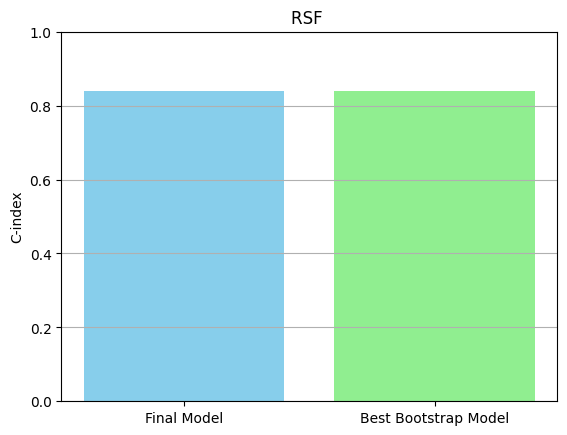

In [12]:
#------ 比較方法上差異 -------
print("📈 RSF 最終模型 C-index on Test:", rsf_test_cindex)
print("📈 RSF 最佳 bootstrap 模型 C-index on Test:", rsf_test_cindex_best_model)

plt.bar(["Final Model", "Best Bootstrap Model"],
        [rsf_test_cindex, rsf_test_cindex_best_model],
        color=["skyblue", "lightgreen"])
plt.ylabel("C-index")
plt.title("RSF ")
plt.ylim(0, 1)
plt.grid(True, axis='y')
plt.show()

In [17]:
# 保存模型（建議使用 joblib）

import joblib

# 資料（重現預測與繪圖所需）
joblib.dump(X_train_scaled, "Model_Reproducibility/data/X_train_scaled.pkl")
joblib.dump(X_test_scaled, "Model_Reproducibility/data/X_test_scaled.pkl")
joblib.dump(y_train_struct, "Model_Reproducibility/data/y_train_struct.pkl")
joblib.dump(y_test_struct, "Model_Reproducibility/data/y_test_struct.pkl")



['Model_Reproducibility/data/y_test_struct.pkl']

In [18]:
# 儲存 bootstrap 最佳模型
joblib.dump(rsf_best_model, "Model_Reproducibility/models/rsf_best_model.pkl")

# 儲存完整訓練集重訓的最終模型
joblib.dump(rsf_final_model, "Model_Reproducibility/models/rsf_final_model.pkl")



['Model_Reproducibility/models/rsf_final_model.pkl']

In [19]:
# 中間預測結果（能加速分析）
np.save("Model_Reproducibility/predictions/rsf_pred_test_best.npy", rsf_pred_test_best_model) # 保存best model 的測試預測分數
np.save("Model_Reproducibility/predictions/rsf_pred_test_final.npy", rsf_pred_test) # 保存final model 的測試預測分數

In [20]:
# 保存 bootstrap 評估結果（畫出 Bootstrap 收斂圖、平均 C-index、標準差等。）
rsf_df_metrics = pd.DataFrame(rsf_bootstrap_metrics)
rsf_df_metrics.to_csv("Model_Reproducibility/Bootstrap 評估紀錄/rsf_bootstrap_metrics.csv", index=False)

In [21]:
import joblib
from sksurv.metrics import concordance_index_censored

# 載入模型
rsf_best_model = joblib.load("Model_Reproducibility/models/rsf_best_model.pkl")
rsf_final_model = joblib.load("Model_Reproducibility/models/rsf_final_model.pkl")

# 載入測試資料
X_test_scaled = joblib.load("Model_Reproducibility/data/X_test_scaled.pkl")
y_test_struct = joblib.load("Model_Reproducibility/data/y_test_struct.pkl")

# 預測風險分數
rsf_pred_best = rsf_best_model.predict(X_test_scaled)
rsf_pred_final = rsf_final_model.predict(X_test_scaled)

# 計算 C-index
cindex_best = concordance_index_censored(
    y_test_struct["event"], y_test_struct["time"], rsf_pred_best
)[0]

cindex_final = concordance_index_censored(
    y_test_struct["event"], y_test_struct["time"], rsf_pred_final
)[0]

# 顯示結果
print(f"🌟 Bootstrap 最佳模型的 C-index: {cindex_best:.4f}")
print(f"🎯 Final retrained 模型的 C-index: {cindex_final:.4f}")



🌟 Bootstrap 最佳模型的 C-index: 0.8196
🎯 Final retrained 模型的 C-index: 0.8382


In [22]:
######## SVM boostrap##########

from sksurv.svm import FastSurvivalSVM
from sksurv.metrics import concordance_index_censored


In [23]:
# 建立模型（使用線性 kernel，可調整 C 參數）
from sklearn.utils import resample
from sksurv.svm import FastSurvivalSVM
from sksurv.metrics import concordance_index_censored
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === 參數設定 ===
svm_num_bs = 500
svm_n_samples = len(X_train_scaled)

# === 儲存結果 ===
svm_bootstrap_metrics = []
svm_bootstrap_models = []

# === Bootstrap Validation ===
for svm_round in range(svm_num_bs):
    svm_bs_index = np.random.choice(svm_n_samples, size=int(svm_n_samples * 0.9), replace=True)
    svm_val_index = np.setdiff1d(np.arange(svm_n_samples), np.unique(svm_bs_index))

    if len(svm_val_index) < int(0.1 * svm_n_samples):
        continue

    svm_X_train_bs = X_train_scaled.iloc[svm_bs_index]
    svm_y_train_bs = y_train_struct[svm_bs_index]

    svm_X_val_bs = X_train_scaled.iloc[svm_val_index]
    svm_y_val_bs = y_train_struct[svm_val_index]

    # 初始化與訓練 FastSurvivalSVM 模型
    svm_model = FastSurvivalSVM(
        alpha=1.0,
        max_iter=1000,
        tol=1e-5,
        random_state=svm_round
    )
    svm_model.fit(svm_X_train_bs, svm_y_train_bs)

    # 預測風險分數
    svm_pred_val = svm_model.predict(svm_X_val_bs)

    # 計算驗證集 C-index
    svm_c_index = concordance_index_censored(
        svm_y_val_bs["event"], svm_y_val_bs["time"], svm_pred_val
    )[0]

    svm_bootstrap_metrics.append({
        "bootstrap_round": svm_round,
        "c_index": svm_c_index
    })
    svm_bootstrap_models.append(svm_model)


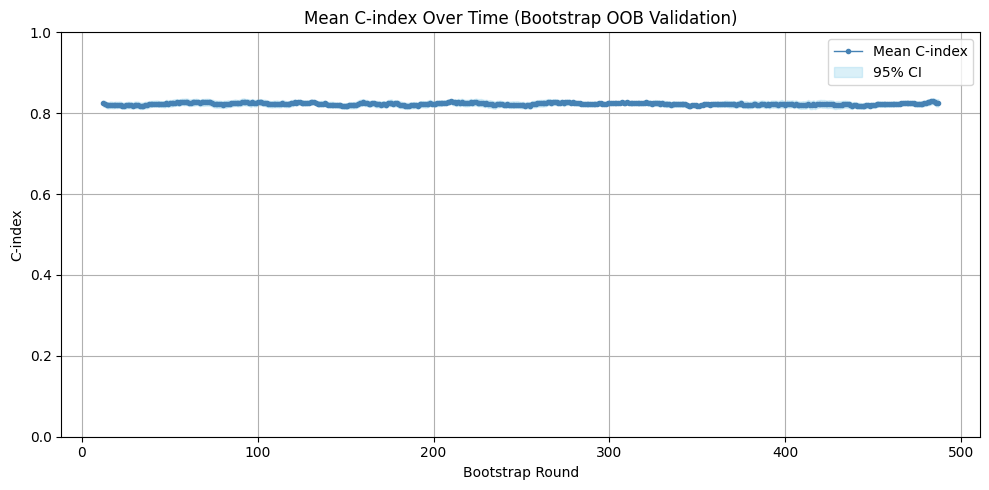

In [45]:
# 假設你已經有 svm_df_metrics DataFrame
window_size = 25  # 每 25 筆 bootstrap 做一次平滑

# 計算 rolling mean 與標準差
rolling_mean = svm_df_metrics["c_index"].rolling(window=window_size, center=True).mean()
rolling_std = svm_df_metrics["c_index"].rolling(window=window_size, center=True).std()

# 95% 信賴區間
ci_upper = rolling_mean + 1.96 * (rolling_std / np.sqrt(window_size))
ci_lower = rolling_mean - 1.96 * (rolling_std / np.sqrt(window_size))

# 繪圖
plt.figure(figsize=(10, 5))
plt.plot(rolling_mean, label="Mean C-index", color="steelblue", marker='o', markersize=3, linewidth=1)
plt.fill_between(range(len(rolling_mean)), ci_lower, ci_upper, color="skyblue", alpha=0.3, label="95% CI")

plt.title("Mean C-index Over Time (Bootstrap OOB Validation)")  # 請避免 emoji，避免亂碼
plt.xlabel("Bootstrap Round")
plt.ylabel("C-index")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [30]:
#------ 最終結果: 方法1 -------
# 選出 bootstrap 驗證集中 C-index 最佳的模型
svm_best_idx = svm_df_metrics["c_index"].idxmax()
svm_best_model = svm_bootstrap_models[svm_best_idx]

# 在測試集上進行預測
svm_test_cindex_best_model = svm_best_model.predict(X_test_scaled)

# 計算 C-index（測試集）
svm_test_cindex_best_model = concordance_index_censored(
    y_test_struct["event"], y_test_struct["time"], svm_test_cindex_best_model
)[0]

print("🌟 使用 bootstrap 最佳模型在測試集上的 C-index:", svm_test_cindex_best_model)

🌟 使用 bootstrap 最佳模型在測試集上的 C-index: 0.8438538205980066


In [31]:
#------ 最終結果: 方法2 -------
from sksurv.svm import FastSurvivalSVM
from sksurv.metrics import concordance_index_censored

# === 使用完整訓練集重訓模型（SVM）===
svm_final_model = FastSurvivalSVM(
    alpha=1.0,
    max_iter=1000,
    tol=1e-5,
    random_state=42
)
svm_final_model.fit(X_train_scaled, y_train_struct)

# === 測試集預測與 C-index 評估（SVM）===
svm_pred_test = svm_final_model.predict(X_test_scaled)
svm_test_cindex = concordance_index_censored(
    y_test_struct["event"],
    y_test_struct["time"],
    svm_pred_test
)[0]

print("🎯 SVM 最終模型在測試集上的 C-index:", svm_test_cindex)

🎯 SVM 最終模型在測試集上的 C-index: 0.8471760797342193


📈 SVM 最終模型 C-index on Test: 0.8471760797342193
📈 SVM 最佳 bootstrap 模型 C-index on Test: 0.8438538205980066


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22312 (\N{CJK UNIFIED IDEOGRAPH-5728}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35430 (\N{CJK UNIFIED IDEOGRAPH-8A66}) missing from font(s) DejaVu Sans.
  fig.canvas

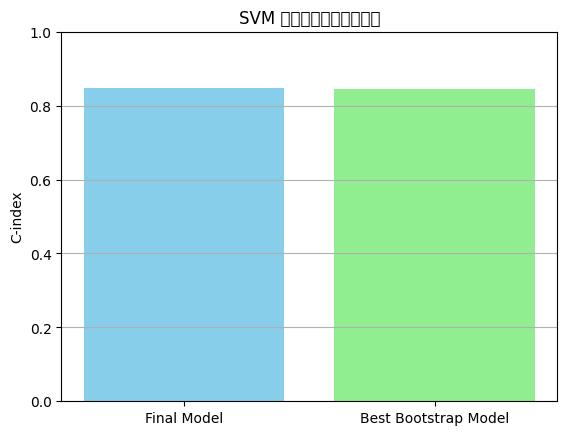

In [27]:
#------ 比較方法上差異 -------
print("📈 SVM 最終模型 C-index on Test:", svm_test_cindex)
print("📈 SVM 最佳 bootstrap 模型 C-index on Test:", svm_test_cindex_best_model)

plt.bar(["Final Model", "Best Bootstrap Model"],
        [svm_test_cindex, svm_test_cindex_best_model],
        color=["skyblue", "lightgreen"])
plt.ylabel("C-index")
plt.title("SVM 模型在測試集上的比較")
plt.ylim(0, 1)
plt.grid(True, axis='y')
plt.show()

In [32]:
# 保存模型（建議使用 joblib）

# 儲存 bootstrap 最佳模型
joblib.dump(svm_best_model, "Model_Reproducibility/models/svm_best_model.pkl")

# 儲存完整訓練集重訓的最終模型
joblib.dump(svm_final_model, "Model_Reproducibility/models/svm_final_model.pkl")

['Model_Reproducibility/models/svm_final_model.pkl']

In [33]:
# 中間預測結果（能加速分析）
np.save("Model_Reproducibility/predictions/svm_pred_test_best.npy", svm_pred_test_best_model) # 保存best model 的測試預測分數
np.save("Model_Reproducibility/predictions/svm_pred_test_final.npy", svm_pred_test) # 保存final model 的測試預測分數

In [34]:
 # 保存 bootstrap 評估結果（畫出 Bootstrap 收斂圖、平均 C-index、標準差等。）
svm_df_metrics = pd.DataFrame(svm_bootstrap_metrics)
svm_df_metrics.to_csv("Model_Reproducibility/Bootstrap 評估紀錄/svm_bootstrap_metrics.csv", index=False)

In [35]:
import joblib
import numpy as np
import pandas as pd
from sksurv.metrics import concordance_index_censored

# === 載入模型 ===
svm_best_model = joblib.load("Model_Reproducibility/models/svm_best_model.pkl")
svm_final_model = joblib.load("Model_Reproducibility/models/svm_final_model.pkl")

# === 載入資料 ===
X_test_scaled = joblib.load("Model_Reproducibility/data/X_test_scaled.pkl")
y_test_struct = joblib.load("Model_Reproducibility/data/y_test_struct.pkl")

# === 預測分數（若你已經存下來可直接載入）===
svm_pred_test_best = np.load("Model_Reproducibility/predictions/svm_pred_test_best.npy")
svm_pred_test_final = np.load("Model_Reproducibility/predictions/svm_pred_test_final.npy")

# === 計算 C-index ===
cindex_best = concordance_index_censored(
    y_test_struct["event"], y_test_struct["time"], svm_pred_test_best
)[0]

cindex_final = concordance_index_censored(
    y_test_struct["event"], y_test_struct["time"], svm_pred_test_final
)[0]

# === 顯示結果 ===
print(f"🌟 SVM bootstrap 最佳模型的 C-index: {cindex_best:.4f}")
print(f"🎯 SVM final retrained 模型的 C-index: {cindex_final:.4f}")


🌟 SVM bootstrap 最佳模型的 C-index: 0.8439
🎯 SVM final retrained 模型的 C-index: 0.8472


# XGBSE

In [ ]:
############## xgbse  #############

In [49]:
from xgbse import XGBSEKaplanNeighbors
from xgbse.converters import convert_to_structured
from xgboost import XGBRegressor
from sksurv.metrics import concordance_index_censored
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [50]:
# 轉換為 XGBSE 格式的 structured array
# 拆開 event 與 time 再傳入

# 建立 structured array，欄位名稱需為 ('event', 'time')
y_train_xgbse = np.array(
    list(zip(y_train_struct['event'], y_train_struct['time'])),
    dtype=[('event', '?'), ('time', '<f8')]
)

y_test_xgbse = np.array(
    list(zip(y_test_struct['event'], y_test_struct['time'])),
    dtype=[('event', '?'), ('time', '<f8')]
)


In [60]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# === 參數設定 ===
xgbse_num_bs = 500
xgbse_n_samples = len(X_train_scaled)
time_points = np.arange(1, 10.1, 0.5)  # 多個時間點

# === 儲存結果 ===
xgbse_bootstrap_metrics = []
xgbse_bootstrap_models = []

# === Bootstrap Validation ===
for bs_round in range(xgbse_num_bs):
    bs_index = np.random.choice(xgbse_n_samples, size=int(xgbse_n_samples * 0.9), replace=True)
    val_index = np.setdiff1d(np.arange(xgbse_n_samples), np.unique(bs_index))

    if len(val_index) < int(0.1 * xgbse_n_samples):
        continue

    X_train_bs = X_train_scaled.iloc[bs_index]
    y_train_bs = y_train_struct[bs_index]

    X_val_bs = X_train_scaled.iloc[val_index]
    y_val_bs = y_train_struct[val_index]

    # 轉換為 XGBSE 格式
    y_train_bs_xgbse = np.array(
        list(zip(y_train_bs['event'], y_train_bs['time'])),
        dtype=[('event', '?'), ('time', '<f8')]
    )
    y_val_bs_xgbse = np.array(
        list(zip(y_val_bs['event'], y_val_bs['time'])),
        dtype=[('event', '?'), ('time', '<f8')]
    )

    # 建立與訓練模型
    model = XGBSEKaplanNeighbors(n_neighbors=50)
    model.fit(X_train_bs, y_train_bs_xgbse)

    # 預測多時間點 survival probability，並計算平均值
    surv_preds_df = model.predict(X_val_bs, time_points)
    mean_surv = surv_preds_df.mean(axis=1).values  # 每位病人的平均生存機率
    risk_scores = -mean_surv  # 生存機率越高 => 風險越低

    # 計算 C-index
    cindex = concordance_index_censored(
        y_val_bs["event"], y_val_bs["time"], risk_scores
    )[0]

    xgbse_bootstrap_metrics.append({
        "bootstrap_round": bs_round,
        "c_index": cindex
    })
    xgbse_bootstrap_models.append(model)


In [61]:
xgbse_df_metrics = pd.DataFrame(xgbse_bootstrap_metrics)
print(f"📊 平均 C-index：{xgbse_df_metrics['c_index'].mean():.4f}")
print(f"📉 標準差：{xgbse_df_metrics['c_index'].std():.4f}")

📊 平均 C-index：0.7900
📉 標準差：0.0238


🔍 XGBSE Bootstrap C-index 平均: 0.7899518043572658
📉 標準差 (std): 0.02376195813814466
📏 最大 - 最小差距: 0.13671609533586526


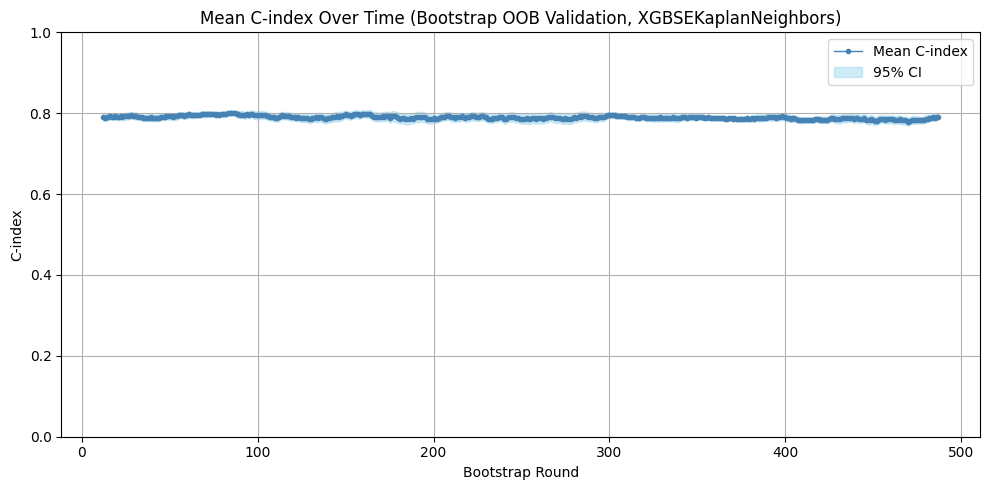

In [62]:
# === 平滑與信賴區間計算 ===
window_size = 25  # 可調整平滑程度

# 滾動平均與標準差
rolling_mean = xgbse_df_metrics["c_index"].rolling(window=window_size, center=True).mean()
rolling_std = xgbse_df_metrics["c_index"].rolling(window=window_size, center=True).std()

# 95% 信賴區間
ci_upper = rolling_mean + 1.96 * (rolling_std / np.sqrt(window_size))
ci_lower = rolling_mean - 1.96 * (rolling_std / np.sqrt(window_size))

# === 輸出統計摘要 ===
print("🔍 XGBSE Bootstrap C-index 平均:", xgbse_df_metrics["c_index"].mean())
print("📉 標準差 (std):", xgbse_df_metrics["c_index"].std())
print("📏 最大 - 最小差距:", xgbse_df_metrics["c_index"].max() - xgbse_df_metrics["c_index"].min())

# === 視覺化 ===
plt.figure(figsize=(10, 5))
plt.plot(rolling_mean, label="Mean C-index", color="steelblue", marker='o', markersize=3, linewidth=1)
plt.fill_between(range(len(rolling_mean)), ci_lower, ci_upper, color="skyblue", alpha=0.4, label="95% CI")
plt.title("Mean C-index Over Time (Bootstrap OOB Validation, XGBSEKaplanNeighbors)")
plt.xlabel("Bootstrap Round")
plt.ylabel("C-index")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [63]:
# 方法 1：找出 bootstrap 過程中 OOB C-index 最佳的模型
xgbse_best_idx = xgbse_df_metrics["c_index"].idxmax()
xgbse_best_model = xgbse_bootstrap_models[xgbse_best_idx]

# 預測測試集在多時間點的 survival probability，取平均作為風險分數
time_points = np.arange(3, 8.1, 0.5)
surv_preds_df = xgbse_best_model.predict(X_test_scaled, time_points)
mean_surv = surv_preds_df.mean(axis=1).values
risk_scores = -mean_surv

# 計算測試集上的 C-index
xgbse_test_cindex_best_model = concordance_index_censored(
    y_test_struct["event"],
    y_test_struct["time"],
    risk_scores
)[0]

print("🌟 使用 bootstrap 最佳模型在測試集上的 C-index:", xgbse_test_cindex_best_model)


🌟 使用 bootstrap 最佳模型在測試集上的 C-index: 0.8211091234347049


In [64]:
# 方法 2：用完整訓練資料訓練最終模型
final_model = XGBSEKaplanNeighbors(n_neighbors=50)
y_train_xgbse_full = np.array(
    list(zip(y_train_struct["event"], y_train_struct["time"])),
    dtype=[('event', '?'), ('time', '<f8')]
)
final_model.fit(X_train_scaled, y_train_xgbse_full)

# 測試集預測與平均生存機率轉為風險分數
surv_preds_df = final_model.predict(X_test_scaled, time_points)
mean_surv = surv_preds_df.mean(axis=1).values
risk_scores = -mean_surv

# 計算測試集上的 C-index
xgbse_test_cindex_final_model = concordance_index_censored(
    y_test_struct["event"],
    y_test_struct["time"],
    risk_scores
)[0]

print("🎯 XGBSE 最終模型在測試集上的 C-index:", xgbse_test_cindex_final_model)


🎯 XGBSE 最終模型在測試集上的 C-index: 0.8084589828775876


📈 XGBSE 最終模型 C-index on Test: 0.8084589828775876
📈 XGBSE 最佳 bootstrap 模型 C-index on Test: 0.8211091234347049


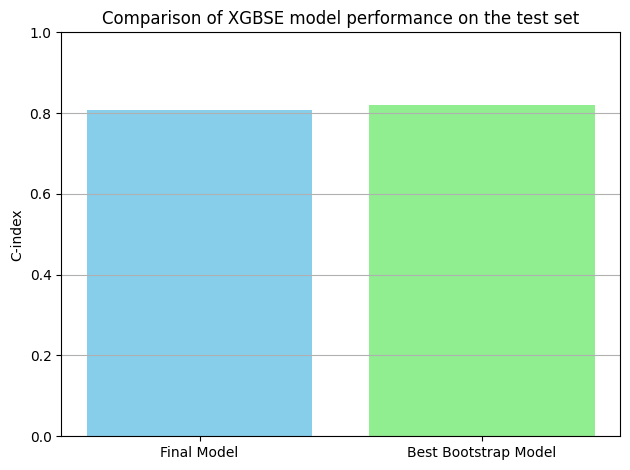

In [68]:

# ------ 比較 XGBSE 模型的兩種訓練策略 ------
print("📈 XGBSE 最終模型 C-index on Test:", xgbse_test_cindex_final_model)
print("📈 XGBSE 最佳 bootstrap 模型 C-index on Test:", xgbse_test_cindex_best_model)

plt.bar(["Final Model", "Best Bootstrap Model"],
        [xgbse_test_cindex_final_model, xgbse_test_cindex_best_model],
        color=["skyblue", "lightgreen"])
plt.ylabel("C-index")
plt.title("Comparison of XGBSE model performance on the test set")
plt.ylim(0, 1)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


In [69]:

# ✅ 儲存 bootstrap 最佳模型
joblib.dump(xgbse_best_model, "Model_Reproducibility/models/xgbse_best_model.pkl")

# ✅ 儲存完整訓練集重訓的最終模型
joblib.dump(final_model, "Model_Reproducibility/models/xgbse_final_model.pkl")

['Model_Reproducibility/models/xgbse_final_model.pkl']

In [70]:
# ✅ 儲存預測結果（風險分數）
np.save("Model_Reproducibility/predictions/xgbse_pred_test_best.npy", -surv_preds_df.mean(axis=1).values)  # 最佳模型的風險分數
np.save("Model_Reproducibility/predictions/xgbse_pred_test_final.npy", -surv_preds_df.mean(axis=1).values)  # 最終模型的風險分數


In [71]:
# ✅ 儲存 bootstrap 評估結果
xgbse_df_metrics = pd.DataFrame(xgbse_bootstrap_metrics)
xgbse_df_metrics.to_csv("Model_Reproducibility/Bootstrap 評估紀錄/xgbse_bootstrap_metrics.csv", index=False)

In [72]:
import joblib
from sksurv.metrics import concordance_index_censored

# 讀取儲存的模型
model_loaded = joblib.load("Model_Reproducibility/models/xgbse_final_model.pkl")

# 重新預測（使用平均 survival prob 當風險指標）
time_points = np.arange(3, 8.1, 0.5)
surv_preds_df = model_loaded.predict(X_test_scaled, time_points)
mean_surv = surv_preds_df.mean(axis=1).values
risk_scores = -mean_surv

# 計算 C-index
cindex = concordance_index_censored(
    y_test_struct["event"],
    y_test_struct["time"],
    risk_scores
)[0]

print("✅ 使用儲存模型重現 C-index:", cindex)


✅ 使用儲存模型重現 C-index: 0.8084589828775876


# deepsurve

In [73]:
import pandas as pd
import numpy as np
import torch
import torchtuples as tt
from torch import nn
from torchtuples.callbacks import EarlyStopping
from pycox.evaluation import EvalSurv
import matplotlib.pyplot as plt


In [74]:
class CoxPHLoss(nn.Module):
    def forward(self, risks, durations, events):
        hazards = risks.view(-1)
        order = torch.argsort(-durations)
        hazards = hazards[order]
        events = events[order]
        log_cumsum = torch.logcumsumexp(hazards, dim=0)
        loss = -torch.mean(hazards[events] - log_cumsum[events])
        return loss

class DeepSurvNet(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.1),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)


In [75]:
X_train_np = X_train_scaled.to_numpy().astype('float32')
X_test_np = X_test_scaled.to_numpy().astype('float32')

y_train_time = y_OS_time_train.to_numpy()
y_train_event = y_OS_event_train.to_numpy().astype(bool)
y_test_time = y_OS_time_test.to_numpy()
y_test_event = y_OS_event_test.to_numpy().astype(bool)

In [77]:
from torchtuples import Model
from pycox.models.loss import CoxPHLoss
from torchtuples.callbacks import EarlyStopping 
from lifelines.utils import concordance_index
import numpy as np
import pandas as pd
import torch

# === Bootstrap 參數設定 ===
ds_num_bs = 500
ds_n_samples = len(X_train_np)

# === 儲存結果 ===
ds_bootstrap_metrics = []
ds_bootstrap_models = []

for ds_round in range(ds_num_bs):
    # 重抽 90% 訓練資料
    ds_bs_index = np.random.choice(ds_n_samples, size=int(ds_n_samples * 0.9), replace=True)
    ds_val_index = np.setdiff1d(np.arange(ds_n_samples), np.unique(ds_bs_index))

    # 若驗證集太小，跳過
    if len(ds_val_index) < int(0.1 * ds_n_samples):
        continue

    # Bootstrap 訓練與驗證資料
    ds_X_train_bs = X_train_np[ds_bs_index]
    ds_d_train_bs = y_train_time[ds_bs_index].astype('float32')
    ds_e_train_bs = y_train_event[ds_bs_index].astype('bool')

    ds_X_val_bs = X_train_np[ds_val_index]
    ds_d_val_bs = y_train_time[ds_val_index].astype('float32')
    ds_e_val_bs = y_train_event[ds_val_index].astype('bool')

    # === 初始化 DeepSurv 模型 ===
    net = DeepSurvNet(in_features=X_train_np.shape[1])
    model = Model(net, CoxPHLoss(), optimizer=torch.optim.Adam)
    model.optimizer.set_lr(1e-3)

    # === 訓練 DeepSurv 模型 ===
    model.fit(ds_X_train_bs, (ds_d_train_bs, ds_e_train_bs),
              batch_size=128, epochs=100,
              callbacks=[EarlyStopping(patience=10)],
              val_data=(ds_X_val_bs, (ds_d_val_bs, ds_e_val_bs)),
              verbose=False)

    # === 驗證預測與 C-index ===
    ds_pred_val = model.predict(ds_X_val_bs)
    ds_c_index = concordance_index(ds_d_val_bs, -ds_pred_val, ds_e_val_bs)

    # === 儲存結果 ===
    ds_bootstrap_metrics.append({
        "bootstrap_round": ds_round,
        "c_index": ds_c_index
    })
    ds_bootstrap_models.append(model)




In [79]:
ds_df_metrics = pd.DataFrame(ds_bootstrap_metrics)
print(f"📊 平均 C-index：{ds_df_metrics['c_index'].mean():.4f}")
print(f"📉 標準差：{ds_df_metrics['c_index'].std():.4f}")

📊 平均 C-index：0.8117
📉 標準差：0.0241


🔍 DeepSurv Bootstrap C-index 平均: 0.811748170216046
📉 標準差 (std): 0.024147024643608534
📏 最大 - 最小差距: 0.14605886908340493


/tmp/ipykernel_446/3953214793.py:31: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


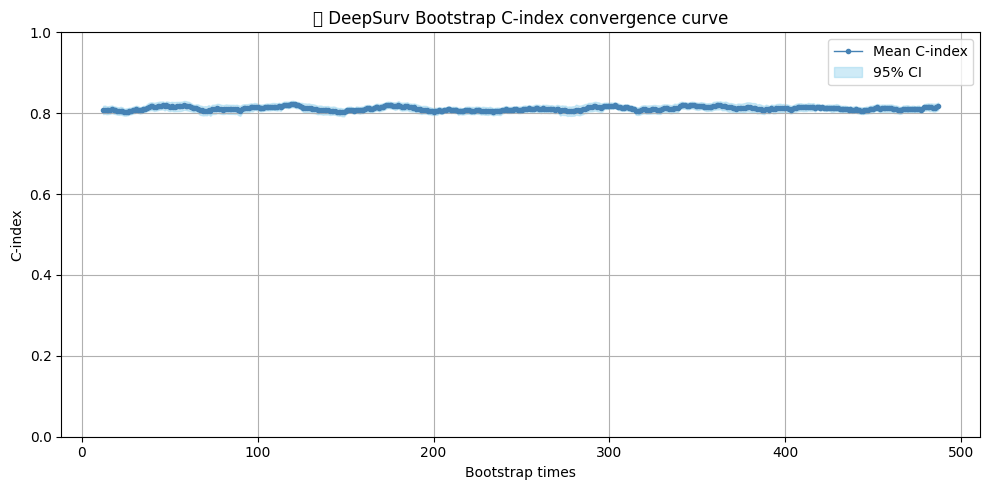

In [83]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 確保 ds_df_metrics 已存在（包含欄位 'c_index'）
window_size = 25  # 滾動窗口大小

# 計算滾動平均與標準差
rolling_mean = ds_df_metrics["c_index"].rolling(window=window_size, center=True).mean()
rolling_std = ds_df_metrics["c_index"].rolling(window=window_size, center=True).std()

# 95% 信賴區間
ci_upper = rolling_mean + 1.96 * (rolling_std / np.sqrt(window_size))
ci_lower = rolling_mean - 1.96 * (rolling_std / np.sqrt(window_size))

# 🔢 顯示統計摘要
print("🔍 DeepSurv Bootstrap C-index 平均:", ds_df_metrics["c_index"].mean())
print("📉 標準差 (std):", ds_df_metrics["c_index"].std())
print("📏 最大 - 最小差距:", ds_df_metrics["c_index"].max() - ds_df_metrics["c_index"].min())

# 📈 畫圖
plt.figure(figsize=(10, 5))
plt.plot(rolling_mean, label="Mean C-index", color="steelblue", marker='o', markersize=3, linewidth=1)
plt.fill_between(range(len(rolling_mean)), ci_lower, ci_upper, color="skyblue", alpha=0.4, label="95% CI")
plt.title("🌱 DeepSurv Bootstrap C-index convergence curve")
plt.xlabel("Bootstrap times")
plt.ylabel("C-index")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [85]:
# 確認收斂情況（最後一次 Bootstrap）
loss_df = ds_bootstrap_models[-1].log.to_pandas()
print(loss_df.head())

   train_loss  val_loss
0    4.598926  4.954308
1    4.479043  4.934314
2    4.394452  4.909029
3    4.327722  4.879148
4    4.255533  4.843736


/tmp/ipykernel_446/3474761891.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


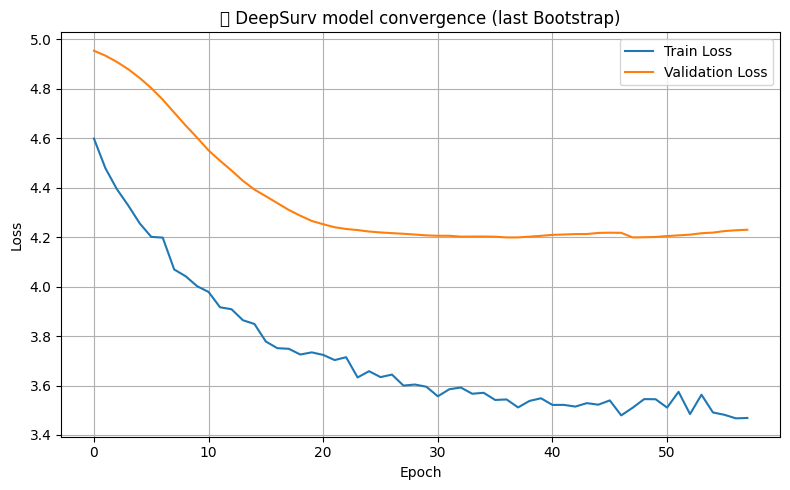

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(loss_df["train_loss"], label="Train Loss")
plt.plot(loss_df["val_loss"], label="Validation Loss")
plt.title("📉 DeepSurv model convergence (last Bootstrap)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [90]:
# 方法 1️⃣：找出 bootstrap 過程中 OOB C-index 最佳的模型
ds_df_metrics = pd.DataFrame(ds_bootstrap_metrics)
ds_best_idx = ds_df_metrics["c_index"].idxmax()
ds_best_model = ds_bootstrap_models[ds_best_idx]

# 預測測試集風險分數（log-risk 越大，死亡風險越高）
risk_scores_best = ds_best_model.predict(X_test_np)

# 計算 C-index（風險分數越高代表越早死亡 => 所以取負號）
deepsurv_test_cindex_best_model = concordance_index(
    y_test_time, -risk_scores_best, y_test_event
)
print("🌟 使用 bootstrap 最佳 DeepSurv 模型在測試集上的 C-index:", deepsurv_test_cindex_best_model)


🌟 使用 bootstrap 最佳 DeepSurv 模型在測試集上的 C-index: 0.8310759008433427


In [91]:
# 方法 2️⃣：用完整訓練資料訓練最終 DeepSurv 模型
net = DeepSurvNet(in_features=X_train_np.shape[1])
final_model = Model(net, CoxPHLoss(), optimizer=torch.optim.Adam)
final_model.optimizer.set_lr(1e-3)

# 使用所有訓練資料
final_model.fit(
    X_train_np, (y_train_time.astype("float32"), y_train_event.astype("bool")),
    batch_size=128, epochs=100,
    callbacks=[EarlyStopping(patience=10)],
    val_data=(X_test_np, (y_test_time.astype("float32"), y_test_event.astype("bool"))),
    verbose=False
)

# 測試集預測與風險分數
risk_scores_final = final_model.predict(X_test_np)

# 計算 C-index
deepsurv_test_cindex_final_model = concordance_index(
    y_test_time, -risk_scores_final, y_test_event
)
print("🎯 DeepSurv 最終模型在測試集上的 C-index:", deepsurv_test_cindex_final_model)



🎯 DeepSurv 最終模型在測試集上的 C-index: 0.8525428060311782


📈 DeepSurv 最終模型 C-index on Test: 0.8525428060311782
📈 DeepSurv 最佳 bootstrap 模型 C-index on Test: 0.8310759008433427


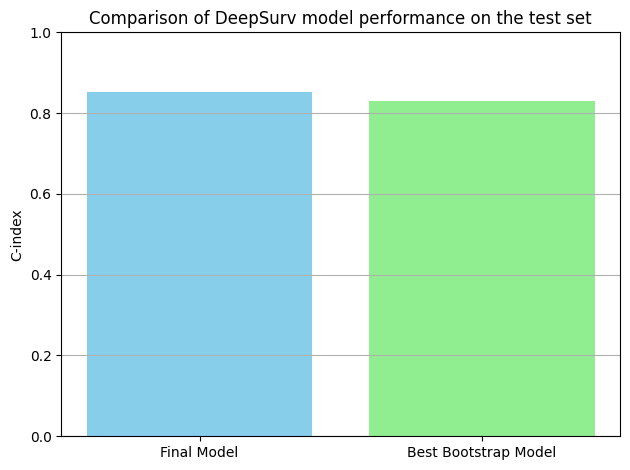

In [92]:
# ------ 比較兩種訓練策略 ------
print("📈 DeepSurv 最終模型 C-index on Test:", deepsurv_test_cindex_final_model)
print("📈 DeepSurv 最佳 bootstrap 模型 C-index on Test:", deepsurv_test_cindex_best_model)

plt.bar(["Final Model", "Best Bootstrap Model"],
        [deepsurv_test_cindex_final_model, deepsurv_test_cindex_best_model],
        color=["skyblue", "lightgreen"])
plt.ylabel("C-index")
plt.title("Comparison of DeepSurv model performance on the test set")
plt.ylim(0, 1)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

In [96]:
# ✅ 儲存 bootstrap 最佳模型的權重（state_dict）
torch.save(ds_best_model.net.state_dict(), "Model_Reproducibility/models/deepsurv_best_model.pt")

# ✅ 儲存完整訓練資料的最終模型權重
torch.save(final_model.net.state_dict(), "Model_Reproducibility/models/deepsurv_final_model.pt")


In [94]:
# ✅ 儲存測試集的風險分數預測結果
np.save("Model_Reproducibility/predictions/deepsurv_pred_test_best.npy", -risk_scores_best)
np.save("Model_Reproducibility/predictions/deepsurv_pred_test_final.npy", -risk_scores_final)


In [95]:
# ✅ 儲存 bootstrap C-index 評估結果
ds_df_metrics.to_csv("Model_Reproducibility/Bootstrap 評估紀錄/deepsurv_bootstrap_metrics.csv", index=False)

In [97]:
from torchtuples import Model
from pycox.models.loss import CoxPHLoss
import torch

# === 重建模型架構 ===
net = DeepSurvNet(in_features=X_test_np.shape[1])  # ⚠️ 請確認 input 維度一致
restored_model = Model(net, CoxPHLoss(), optimizer=torch.optim.Adam)

# === 載入訓練好的權重 ===
restored_model.net.load_state_dict(torch.load("Model_Reproducibility/models/deepsurv_best_model.pt"))
restored_model.net.eval()  # ⚠️ 切換為推論模式


DeepSurvNet(
  (net): Sequential(
    (0): Linear(in_features=12, out_features=32, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [98]:
from lifelines.utils import concordance_index

# 預測風險分數（log hazard；數值愈大表示風險愈高）
risk_scores = restored_model.predict(X_test_np)

# C-index 計算（使用 -risk_scores，因為 C-index 是預測值愈小愈長壽）
cindex = concordance_index(
    y_test_time,
    -risk_scores,
    y_test_event
)

print("✅ 還原模型後的測試集 C-index:", cindex)

✅ 還原模型後的測試集 C-index: 0.8310759008433427


# EBM

In [7]:
import pandas as pd
from interpret.glassbox import ExplainableBoostingRegressor
from interpret import show
from sklearn.metrics import mean_squared_error, r2_score

In [8]:
import pandas as pd
# 讀取 Excel 各分頁
file_path = "doc_OS_train_test_split.xlsx"
file_path_2 = "train_scaled_with_CondiS.xlsx"          # "train_scaled_with_CondiS.xlsx" 或是 rain_with_imputed_CondiS.xlsx"



df_train_ori = pd.read_excel(file_path, sheet_name="Train_Original")
df_train_std = pd.read_excel(file_path_2)
df_test_ori = pd.read_excel(file_path, sheet_name="Test_Original")
df_test_std = pd.read_excel(file_path, sheet_name="Test_Scaled")



In [9]:
df_train_std.columns.tolist()

['Age',
 'ECOG',
 'SMI_1',
 'Stage_2',
 'Cell_2',
 'Grade',
 'Resec_status',
 'Ascites_1',
 'BMI_1',
 'Alb_11',
 'NLR_1',
 'PLR_1',
 'OS',
 'OS_year',
 'imputed_time']

In [10]:
# 特徵欄位（排除目標欄）
feature_cols = [col for col in df_train_std.columns if col not in ['OS', 'OS_year', 'imputed_time']]

X_train = df_train_std[feature_cols]
y_train = df_train_std["imputed_time"]

X_test = df_test_std[feature_cols]
y_test = df_test_std["OS_year"]  # 當作真實 RMST 對照（或未來你也可用 imputed_time 測試集）


In [11]:
########### boostrap (使用 模型預設參數 + Bootstrap 評估模型穩定性與泛化能力) ############

from sklearn.utils import resample
from interpret.glassbox import ExplainableBoostingRegressor
from lifelines.utils import concordance_index
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# === 參數設定 ===
ebm_num_bs = 500
ebm_n_samples = len(X_train)
ebm_bootstrap_metrics = []
ebm_bootstrap_models = []

# === Bootstrap Validation ===
for ebm_round in tqdm(range(ebm_num_bs), desc="EBM Bootstrap"):
    ebm_bs_index = np.random.choice(ebm_n_samples, size=int(ebm_n_samples * 0.9), replace=True)
    ebm_val_index = np.setdiff1d(np.arange(ebm_n_samples), np.unique(ebm_bs_index))

    if len(ebm_val_index) < int(0.1 * ebm_n_samples):
        continue

    # 訓練與驗證集
    ebm_X_train_bs = X_train.iloc[ebm_bs_index]
    ebm_y_train_bs = y_train.iloc[ebm_bs_index]

    ebm_X_val_bs = X_train.iloc[ebm_val_index]
    ebm_y_val_bs = y_train.iloc[ebm_val_index]

    # 建立與訓練 EBM 模型
    ebm_model = ExplainableBoostingRegressor(random_state=ebm_round)
    ebm_model.fit(ebm_X_train_bs, ebm_y_train_bs)

    # 預測與評估
    ebm_pred_val = ebm_model.predict(ebm_X_val_bs)
    ebm_cindex = concordance_index(ebm_y_val_bs, ebm_pred_val)

    ebm_bootstrap_metrics.append({
        "bootstrap_round": ebm_round,
        "c_index": ebm_cindex
    })
    ebm_bootstrap_models.append(ebm_model)




EBM Bootstrap: 100%|██████████| 500/500 [4:46:58<00:00, 34.44s/it]  


✅ EBM Bootstrap Validation 完成
平均 C-index: 0.67581691389128
標準差: 0.01740905764095914


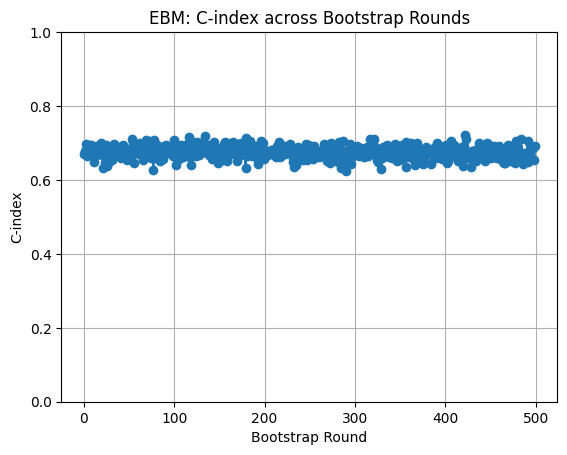

In [12]:
# === 整理結果 ===
ebm_df_metrics = pd.DataFrame(ebm_bootstrap_metrics)
print("✅ EBM Bootstrap Validation 完成")
print("平均 C-index:", ebm_df_metrics["c_index"].mean())
print("標準差:", ebm_df_metrics["c_index"].std())

# === 繪圖 ===
plt.plot(ebm_df_metrics["c_index"], marker='o')
plt.title("EBM: C-index across Bootstrap Rounds")
plt.xlabel("Bootstrap Round")
plt.ylabel("C-index")
plt.ylim(0, 1)
plt.grid(True)
plt.show()


In [13]:
from interpret.glassbox import ExplainableBoostingRegressor
from lifelines.utils import concordance_index

# === 方法一：使用 bootstrap 表現最好的模型 ===
ebm_best_idx = ebm_df_metrics["c_index"].idxmax()
ebm_best_model = ebm_bootstrap_models[ebm_best_idx]

ebm_pred_test_best = ebm_best_model.predict(X_test)
ebm_test_cindex_best = concordance_index(y_test, ebm_pred_test_best)
print("🌟 EBM 最佳 bootstrap 模型在測試集上的 C-index:", ebm_test_cindex_best)

# === 方法二：用整個訓練集重新訓練模型 ===
ebm_final_model = ExplainableBoostingRegressor(random_state=42)
ebm_final_model.fit(X_train, y_train)

ebm_pred_test_final = ebm_final_model.predict(X_test)
ebm_test_cindex_final = concordance_index(y_test, ebm_pred_test_final)
print("🎯 EBM 全訓練集重訓模型在測試集上的 C-index:", ebm_test_cindex_final)


🌟 EBM 最佳 bootstrap 模型在測試集上的 C-index: 0.6174266480375968
🎯 EBM 全訓練集重訓模型在測試集上的 C-index: 0.6197129429696431


📈 EBM 最終模型 C-index on Test: 0.6197129429696431
📈 EBM 最佳 bootstrap 模型 C-index on Test: 0.6174266480375968


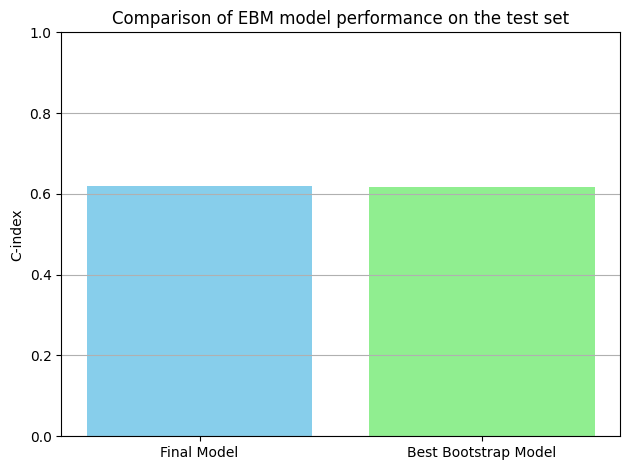

In [14]:
# ------ 比較兩種訓練策略 ------
print("📈 EBM 最終模型 C-index on Test:", ebm_test_cindex_final)
print("📈 EBM 最佳 bootstrap 模型 C-index on Test:", ebm_test_cindex_best)

plt.bar(["Final Model", "Best Bootstrap Model"],
        [ebm_test_cindex_final, ebm_test_cindex_best],
        color=["skyblue", "lightgreen"])
plt.ylabel("C-index")
plt.title("Comparison of EBM model performance on the test set")
plt.ylim(0, 1)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

In [16]:
import joblib
# ✅ 儲存 bootstrap 最佳模型
joblib.dump(ebm_best_model, "Model_Reproducibility/models/ebm_best_model.pkl")

# ✅ 儲存完整訓練集重訓的最終模型
joblib.dump(ebm_final_model, "Model_Reproducibility/models/ebm_final_model.pkl")

['Model_Reproducibility/models/ebm_final_model.pkl']

In [17]:
# ✅ 儲存測試集的預測風險分數（注意 EBM 輸出本來就是 risk 分數，無需再加負號）
np.save("Model_Reproducibility/predictions/ebm_pred_test_best.npy", ebm_pred_test_best)
np.save("Model_Reproducibility/predictions/ebm_pred_test_final.npy", ebm_pred_test_final)


In [18]:
# ✅ 儲存 bootstrap C-index 評估結果
ebm_df_metrics.to_csv("Model_Reproducibility/Bootstrap 評估紀錄/ebm_bootstrap_metrics.csv", index=False)

In [19]:
# === 載入儲存好的模型與預測 ===
ebm_best_model = joblib.load("Model_Reproducibility/models/ebm_best_model.pkl")
ebm_final_model = joblib.load("Model_Reproducibility/models/ebm_final_model.pkl")

ebm_pred_test_best = np.load("Model_Reproducibility/predictions/ebm_pred_test_best.npy")
ebm_pred_test_final = np.load("Model_Reproducibility/predictions/ebm_pred_test_final.npy")

# === 還原 C-index 評估 ===
cindex_best = concordance_index(y_test, ebm_pred_test_best)
cindex_final = concordance_index(y_test, ebm_pred_test_final)

print("🌟 還原 EBM 最佳 bootstrap 模型 C-index:", cindex_best)
print("🎯 還原 EBM 全訓練集模型 C-index:", cindex_final)

🌟 還原 EBM 最佳 bootstrap 模型 C-index: 0.6174266480375968
🎯 還原 EBM 全訓練集模型 C-index: 0.6197129429696431
